# Supply Chain & Inventory Analytics — Data Profiling

## Objective

This notebook profiles the raw supply-chain dataset and validates its
structure, quality, time coverage, business dimensions, and data grain.

Detailed business analysis is performed separately in:

`02_business_analysis.ipynb`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
DATA_PATH = Path("../data/raw/supply_chain_dataset.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at: {DATA_PATH.resolve()}"
    )

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset loaded successfully.
Rows: 91,250
Columns: 15


## 1. Dataset Overview

In [3]:
print("Dataset Shape")
print("-" * 40)
print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")

print("\nColumn Names")
print("-" * 40)

for column in df.columns:
    print(column)

Dataset Shape
----------------------------------------
Rows: 91,250
Columns: 15

Column Names
----------------------------------------
Date
SKU_ID
Warehouse_ID
Supplier_ID
Region
Units_Sold
Inventory_Level
Supplier_Lead_Time_Days
Reorder_Point
Order_Quantity
Unit_Cost
Unit_Price
Promotion_Flag
Stockout_Flag
Demand_Forecast


In [4]:
display(df.head())

,Date,SKU_ID,Warehouse_ID,Supplier_ID,Region,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Stockout_Flag,Demand_Forecast
0,2024-01-01,SKU_1,WH_1,SUP_8,West,10,592,14,379,0,13.95,20.48,0,0,8.52
1,2024-01-02,SKU_1,WH_1,SUP_8,West,17,575,14,379,0,13.95,20.48,0,0,18.63
2,2024-01-03,SKU_1,WH_1,SUP_8,North,35,540,14,379,0,13.95,20.48,1,0,39.62
3,2024-01-04,SKU_1,WH_1,SUP_8,South,24,516,14,379,0,13.95,20.48,0,0,19.43
4,2024-01-05,SKU_1,WH_1,SUP_8,West,21,495,14,379,0,13.95,20.48,0,0,18.70


In [5]:
display(df.tail())

,Date,SKU_ID,Warehouse_ID,Supplier_ID,Region,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Stockout_Flag,Demand_Forecast
91245,2024-12-26,SKU_50,WH_5,SUP_10,South,17,352,7,283,0,6.65,9.60,0,0,19.82
91246,2024-12-27,SKU_50,WH_5,SUP_10,South,21,331,7,283,0,6.65,9.60,0,0,27.96
91247,2024-12-28,SKU_50,WH_5,SUP_10,East,17,314,7,283,0,6.65,9.60,0,0,22.13
91248,2024-12-29,SKU_50,WH_5,SUP_10,South,24,290,7,283,0,6.65,9.60,1,0,24.11
91249,2024-12-30,SKU_50,WH_5,SUP_10,West,15,275,7,283,0,6.65,9.60,1,0,20.19


In [6]:
print("Data Types")
print("-" * 40)

display(
    df.dtypes.to_frame("Data_Type")
)

Data Types
----------------------------------------


,Data_Type
Date,object
SKU_ID,object
Warehouse_ID,object
Supplier_ID,object
Region,object
Units_Sold,int64
Inventory_Level,int64
Supplier_Lead_Time_Days,int64
Reorder_Point,int64
Order_Quantity,int64


In [7]:
print("Numerical Summary")

display(
    df.describe().T
)

Numerical Summary


,count,mean,std,min,25%,50%,75%,max
Units_Sold,"91,250.00",20.05,9.07,0.00,13.00,20.00,27.00,59.00
Inventory_Level,"91,250.00",471.52,133.49,168.00,370.00,461.00,564.00,990.00
Supplier_Lead_Time_Days,"91,250.00",7.98,3.91,2.00,4.00,8.00,11.00,14.00
Reorder_Point,"91,250.00",300.07,54.88,201.00,252.00,300.00,346.00,398.00
Order_Quantity,"91,250.00",19.27,82.34,0.00,0.00,0.00,0.00,499.00
Unit_Cost,"91,250.00",12.20,4.57,5.02,8.18,11.99,16.32,19.76
Unit_Price,"91,250.00",18.26,7.12,6.95,12.00,18.18,23.39,35.10
Promotion_Flag,"91,250.00",0.10,0.30,0.00,0.00,0.00,0.00,1.00
Stockout_Flag,"91,250.00",0.00,0.00,0.00,0.00,0.00,0.00,0.00
Demand_Forecast,"91,250.00",20.08,9.50,0.00,12.95,19.95,26.93,61.42


In [8]:
print("Categorical Summary")

display(
    df.describe(include="object").T
)

Categorical Summary


,count,unique,top,freq
Date,91250,365,2024-01-01,250
SKU_ID,91250,50,SKU_1,1825
Warehouse_ID,91250,5,WH_1,18250
Supplier_ID,91250,10,SUP_7,12410
Region,91250,4,North,22974


## 2. Data Quality Assessment

In [9]:
quality_report = pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str).values,
    "Missing_Values": df.isna().sum().values,
    "Missing_Percentage": (
        df.isna().mean().values * 100
    ).round(2),
    "Unique_Values": df.nunique(dropna=False).values
})

display(quality_report)

,Column,Data_Type,Missing_Values,Missing_Percentage,Unique_Values
0,Date,object,0,0.00,365
1,SKU_ID,object,0,0.00,50
2,Warehouse_ID,object,0,0.00,5
3,Supplier_ID,object,0,0.00,10
4,Region,object,0,0.00,4
5,Units_Sold,int64,0,0.00,58
6,Inventory_Level,int64,0,0.00,781
7,Supplier_Lead_Time_Days,int64,0,0.00,13
8,Reorder_Point,int64,0,0.00,142
9,Order_Quantity,int64,0,0.00,301


In [10]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count:,}")

Duplicate rows: 0


In [11]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns

negative_report = pd.DataFrame({
    "Column": numeric_columns,
    "Negative_Value_Count": [
        (df[column] < 0).sum()
        for column in numeric_columns
    ]
})

display(negative_report)

,Column,Negative_Value_Count
0,Units_Sold,0
1,Inventory_Level,0
2,Supplier_Lead_Time_Days,0
3,Reorder_Point,0
4,Order_Quantity,0
5,Unit_Cost,0
6,Unit_Price,0
7,Promotion_Flag,0
8,Stockout_Flag,0
9,Demand_Forecast,0


In [12]:
infinite_report = pd.DataFrame({
    "Column": numeric_columns,
    "Infinite_Value_Count": [
        np.isinf(df[column]).sum()
        for column in numeric_columns
    ]
})

display(infinite_report)

,Column,Infinite_Value_Count
0,Units_Sold,0
1,Inventory_Level,0
2,Supplier_Lead_Time_Days,0
3,Reorder_Point,0
4,Order_Quantity,0
5,Unit_Cost,0
6,Unit_Price,0
7,Promotion_Flag,0
8,Stockout_Flag,0
9,Demand_Forecast,0


## 3. Date Validation

In [13]:
df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)

invalid_dates = df["Date"].isna().sum()

print(f"Invalid dates: {invalid_dates:,}")
print(f"Minimum date: {df['Date'].min()}")
print(f"Maximum date: {df['Date'].max()}")
print(f"Unique dates: {df['Date'].nunique():,}")

Invalid dates: 0
Minimum date: 2024-01-01 00:00:00
Maximum date: 2024-12-30 00:00:00
Unique dates: 365


In [14]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.strftime("%b")

monthly_records = (
    df.groupby(
        ["Year", "Month", "Month_Name"]
    )
    .size()
    .reset_index(name="Record_Count")
    .sort_values(["Year", "Month"])
)

display(monthly_records)

,Year,Month,Month_Name,Record_Count
0,2024,1,Jan,7750
1,2024,2,Feb,7250
2,2024,3,Mar,7750
3,2024,4,Apr,7500
4,2024,5,May,7750
5,2024,6,Jun,7500
6,2024,7,Jul,7750
7,2024,8,Aug,7750
8,2024,9,Sep,7500
9,2024,10,Oct,7750


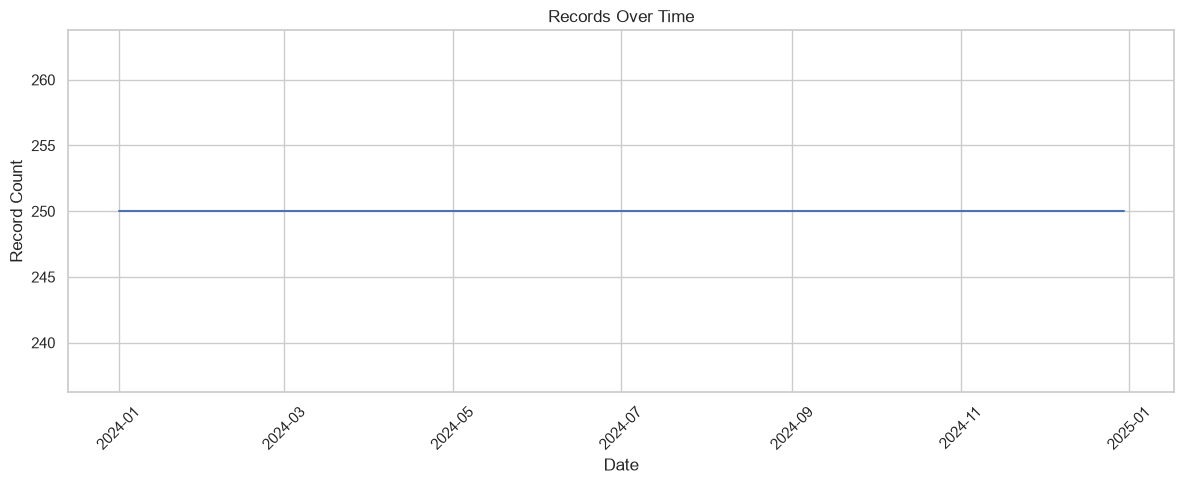

In [15]:
daily_records = (
    df.groupby("Date")
    .size()
    .reset_index(name="Record_Count")
)

plt.figure(figsize=(12, 5))

plt.plot(
    daily_records["Date"],
    daily_records["Record_Count"]
)

plt.title("Records Over Time")
plt.xlabel("Date")
plt.ylabel("Record Count")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Business Dimensions

In [16]:
dimension_columns = [
    "SKU_ID",
    "Warehouse_ID",
    "Supplier_ID",
    "Region"
]

dimension_summary = pd.DataFrame({
    "Dimension": dimension_columns,
    "Unique_Values": [
        df[column].nunique()
        for column in dimension_columns
    ]
})

display(dimension_summary)

,Dimension,Unique_Values
0,SKU_ID,50
1,Warehouse_ID,5
2,Supplier_ID,10
3,Region,4


In [17]:
for column in dimension_columns:

    print(f"\n{column}")

    display(
        df[column]
        .value_counts()
        .rename_axis(column)
        .reset_index(name="Record_Count")
    )


SKU_ID


,SKU_ID,Record_Count
0,SKU_1,1825
1,SKU_2,1825
2,SKU_3,1825
3,SKU_4,1825
4,SKU_5,1825
5,SKU_6,1825
6,SKU_7,1825
7,SKU_8,1825
8,SKU_9,1825
9,SKU_10,1825



Warehouse_ID


,Warehouse_ID,Record_Count
0,WH_1,18250
1,WH_2,18250
2,WH_3,18250
3,WH_4,18250
4,WH_5,18250



Supplier_ID


,Supplier_ID,Record_Count
0,SUP_7,12410
1,SUP_8,10220
2,SUP_1,10220
3,SUP_10,9855
4,SUP_2,9490
5,SUP_4,9125
6,SUP_5,8395
7,SUP_3,8395
8,SUP_6,7300
9,SUP_9,5840



Region


,Region,Record_Count
0,North,22974
1,East,22934
2,South,22720
3,West,22622


## 5. Data Grain Validation

Expected operational grain:

`Date + SKU_ID + Warehouse_ID`

In [18]:
business_key = [
    "Date",
    "SKU_ID",
    "Warehouse_ID"
]

total_records = len(df)

unique_business_keys = (
    df[business_key]
    .drop_duplicates()
    .shape[0]
)

duplicate_business_keys = (
    total_records - unique_business_keys
)

print(f"Total records: {total_records:,}")
print(f"Unique business keys: {unique_business_keys:,}")
print(
    f"Duplicate business-key records: "
    f"{duplicate_business_keys:,}"
)

Total records: 91,250
Unique business keys: 91,250
Duplicate business-key records: 0


In [19]:
business_key_duplicates = (
    df.groupby(business_key)
    .size()
    .reset_index(name="Record_Count")
)

business_key_duplicates = (
    business_key_duplicates[
        business_key_duplicates["Record_Count"] > 1
    ]
)

display(
    business_key_duplicates.head(20)
)

,Date,SKU_ID,Warehouse_ID,Record_Count


## 6. Profiling Summary

In [20]:
profiling_summary = pd.DataFrame({
    "Metric": [
        "Total Records",
        "Total Columns",
        "Unique SKUs",
        "Unique Warehouses",
        "Unique Suppliers",
        "Unique Regions",
        "Unique Dates",
        "Duplicate Rows",
        "Duplicate Business Keys",
        "Invalid Dates"
    ],
    "Value": [
        len(df),
        df.shape[1],
        df["SKU_ID"].nunique(),
        df["Warehouse_ID"].nunique(),
        df["Supplier_ID"].nunique(),
        df["Region"].nunique(),
        df["Date"].nunique(),
        duplicate_count,
        duplicate_business_keys,
        invalid_dates
    ]
})

display(profiling_summary)

,Metric,Value
0,Total Records,91250
1,Total Columns,18
2,Unique SKUs,50
3,Unique Warehouses,5
4,Unique Suppliers,10
5,Unique Regions,4
6,Unique Dates,365
7,Duplicate Rows,0
8,Duplicate Business Keys,0
9,Invalid Dates,0


## Conclusion

The dataset has been profiled for structure, data quality, temporal coverage,
business dimensions, and operational grain.

The validated dataset is used by `02_business_analysis.ipynb` for detailed
business analysis.